# VERSION C: LANGGRAPH

## Orchestration

This version uses a hand-built LangGraph workflow without create_agent()

## Imports and Setup

In [37]:
import json 
import requests

from dotenv import load_dotenv, find_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from langgraph.graph import (StateGraph, START, END, MessagesState)
from langchain_core.messages import ToolMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command

load_dotenv(find_dotenv(usecwd=True))
MODEL = "gpt-4o-mini"

llm = ChatOpenAI(model=MODEL, temperature=0)


## Weather Tool

In [4]:
@tool
def get_destination_weather(city: str,days_ahead: int = 7) -> dict:
    """
    Get the weather forecast for a destination city.
    Use this for weather, temperature, rain, or packing questions.
    """

    try:
        geo_url = (
            "https://geocoding-api.open-meteo.com/v1/search"
        )

        geo_response = requests.get(
            geo_url,
            params={
                "name": city,
                "count": 1,
                "language": "en",
                "format": "json"
            }
        )

        geo_data = geo_response.json()

        if not geo_data.get("results"):
            raise ValueError(f"Could not resolve city: {city}")

        location = geo_data["results"][0]

        latitude = location["latitude"]
        longitude = location["longitude"]
        city_name = location["name"]

        weather_url = ("https://api.open-meteo.com/v1/forecast")

        weather_response = requests.get(
            weather_url,
            params={
                "latitude": latitude,
                "longitude": longitude,
                "daily": (
                    "temperature_2m_min,"
                    "temperature_2m_max,"
                    "precipitation_probability_max"
                ),
                "forecast_days": 16,
                "timezone": "auto"
            }
        )

        weather_data = weather_response.json()

        if "daily" not in weather_data:
            raise ValueError("Could not get weather data")

        daily = weather_data["daily"]

        return {
            "city": city_name,
            "date": daily["time"][days_ahead],
            "min_temp_c": daily["temperature_2m_min"][days_ahead],
            "max_temp_c": daily["temperature_2m_max"][days_ahead],
            "rain_probability": daily["precipitation_probability_max"][days_ahead]
        }

    except Exception as e:

        return {
            "error": f"{type(e).__name__}: {e}"
        }

## Currency Tool

In [5]:
@tool
def convert_currency(amount: float, from_currency: str, to_currency: str) -> dict:
    """
    Convert money from currency to another.
    """

    try:
        url = "https://api.frankfurter.app/latest"
        response = requests.get(
            url,
            params={
                "amount": amount,
                "from": from_currency.upper(),
                "to": to_currency.upper()
            }
        )

        data = response.json()
        if "rates" not in data:
            raise ValueError("Currency conversion failed")

        converted_amount = (data["rates"][to_currency.upper()])

        return{
            "amount": amount,
            "from_currency": from_currency.upper(),
            "to_currency": to_currency.upper(),
            "converted_amount": converted_amount
        }

    except Exception as e:
        return{
            "error": f"{type(e).__name__}: {e}"
        }

## Trip Cost Tool

In [6]:
@tool
def estimate_trip_cost(
    city: str,
    days: int,
    travel_style: str = "budget"
) -> dict:
    """
    Estimate the trip cost in INR.
    """

    city_costs = {

        "ooty": {
            "budget": 2500,
            "mid-range": 4500,
            "luxury": 8000
        },

        "manali": {
            "budget": 3000,
            "mid-range": 5500,
            "luxury": 10000
        },

        "bangkok": {
            "budget": 4500,
            "mid-range": 6800,
            "luxury": 12000
        },

        "bali": {
            "budget": 5000,
            "mid-range": 8000,
            "luxury": 15000
        }
    }

    city_key = city.lower()

    if city_key in city_costs:

        daily_cost = city_costs[
            city_key
        ][travel_style]

        note = None

    else:

        default_costs = {
            "budget": 3500,
            "mid-range": 6000,
            "luxury": 10000
        }

        daily_cost = default_costs[
            travel_style
        ]

        note = (
            f"Unknown city '{city}'. "
            "Using default cost estimates."
        )

    result = {
        "city": city,
        "days": days,
        "travel_style": travel_style,
        "estimated_cost_inr": daily_cost * days
    }

    if note:
        result["note"] = note

    return result

## Agent State and Tool List

In [7]:
class AgentState(MessagesState):
    tool_calls_made: int

tools = [get_destination_weather, convert_currency, estimate_trip_cost]
llm_with_tools = llm.bind_tools(tools)

## Call Model

In [36]:
def call_model(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}

## Routing Function

In [9]:
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"

    return END

## Tool Execution Node with Command

In [10]:
def execute_tools(state: AgentState):
    last_message = state["messages"][-1]
    tool_map = {
        "get_destination_weather": get_destination_weather,
        "convert_currency": convert_currency,
        "estimate_trip_cost": estimate_trip_cost
    }

    tool_messages = []
    call_count = state.get("tool_calls_made", 0)
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]
        
        try:
            result = tool_map[tool_name].invoke(tool_args)

        except Exception as e:
            result = {
                "error": f"{type(e).__name__}: {e}"
            }

        tool_messages.append(
            ToolMessage(
                content=json.dumps(result),
                tool_call_id=tool_id
            )
        )
        call_count += 1

    return Command(
        update={
            "messages": tool_messages,
            "tool_calls_made": call_count
        }
    )

## State Graph

In [11]:
builder = StateGraph(AgentState)

builder.add_node("call_model", call_model)
builder.add_node("tools", execute_tools)

builder.add_edge(START, "call_model")

builder.add_conditional_edges("call_model", should_continue, {"tools": "tools", END: END})

builder.add_edge("tools", "call_model")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

print("Tripbuddy LangGraph agent created successfully!")


Tripbuddy LangGraph agent created successfully!


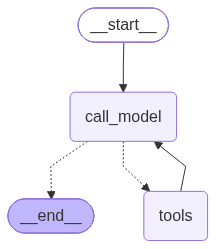

In [18]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

## Run Function

In [23]:
def run_tripbuddy(user_message, thread_id="default"):

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    print(f"USER: {user_message}\n")

    final_answer = None

    for chunk in graph.stream(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message
                }
            ],
            "tool_calls_made": 0
        },
        config=config,
        stream_mode="updates"
    ):

        if "call_model" in chunk:

            message = chunk["call_model"]["messages"][-1]

            if message.tool_calls:

                for tool_call in message.tool_calls:

                    print(
                        f"MODEL: Calling tool: "
                        f"{tool_call['name']}"
                    )

                    print(
                        f"Arguments: "
                        f"{tool_call['args']}\n"
                    )

            elif message.content:

                final_answer = message.content

        if "tools" in chunk:

            messages = chunk["tools"]["messages"]

            for message in messages:

                print(
                    f"TOOL RESULT: "
                    f"{message.content}\n"
                )

    print("FINAL ANSWER:")
    print(final_answer)

    return final_answer

## Query 1 — Weather

What's the weather in Ooty tomorrow?

In [32]:
answer = run_tripbuddy(
    "What's the weather in Ooty tomorrow?",
    thread_id="query1"
)

USER: What's the weather in Ooty tomorrow?

MODEL: Calling tool: get_destination_weather
Arguments: {'city': 'Ooty', 'days_ahead': 1}

TOOL RESULT: {"city": "Udhagamandalam", "date": "2026-09-13", "min_temp_c": 13.9, "max_temp_c": 19.9, "rain_probability": 47}

FINAL ANSWER:
Tomorrow in Ooty (Udhagamandalam), the weather is expected to have a minimum temperature of 13.9°C and a maximum temperature of 19.9°C. There is a 47% chance of rain, so it would be a good idea to carry an umbrella or raincoat if you're planning to go out!


## Query 2 — Weather and Trip Cost

I'm going to Manali for 4 days next week —
should I pack for rain, and roughly what will it cost?

In [33]:
answer = run_tripbuddy(
    "I'm going to Manali for 4 days next week should I pack for rain, and roughly what will it cost?",
    thread_id="query2"
)

USER: I'm going to Manali for 4 days next week should I pack for rain, and roughly what will it cost?

MODEL: Calling tool: get_destination_weather
Arguments: {'city': 'Manali', 'days_ahead': 7}

MODEL: Calling tool: estimate_trip_cost
Arguments: {'city': 'Manali', 'days': 4}

TOOL RESULT: {"city": "Manali", "date": "2026-09-19", "min_temp_c": 25.4, "max_temp_c": 33.7, "rain_probability": 89}

TOOL RESULT: {"city": "Manali", "days": 4, "travel_style": "budget", "estimated_cost_inr": 12000}

FINAL ANSWER:
Next week in Manali, there's a high probability of rain (89%), so it's advisable to pack for wet weather.

As for the cost, a budget trip for 4 days in Manali is estimated to be around ₹12,000.


## Query 3 — Currency Conversion

Convert 500 USD to INR for my Bali trip.

In [34]:
answer = run_tripbuddy(
    "Convert 500 USD to INR for my Bali trip.",
    thread_id="query3"
)

USER: Convert 500 USD to INR for my Bali trip.

MODEL: Calling tool: convert_currency
Arguments: {'amount': 500, 'from_currency': 'USD', 'to_currency': 'INR'}

TOOL RESULT: {"amount": 500.0, "from_currency": "USD", "to_currency": "INR", "converted_amount": 47778}

FINAL ANSWER:
500 USD is approximately 47,778 INR for your Bali trip.


## Query 4 — All Three Tools

Planning a 6-day trip to Bangkok. What's the weather, what will it cost in INR, and if I already have 20,000 THB, how much is that in INR?

In [35]:
answer = run_tripbuddy(
    "Planning a 6-day trip to Bangkok. What's the weather, what will it cost in INR, and if I already have 20,000 THB, how much is that in INR?",
    thread_id="bangkok_trip"
)

USER: Planning a 6-day trip to Bangkok. What's the weather, what will it cost in INR, and if I already have 20,000 THB, how much is that in INR?

MODEL: Calling tool: get_destination_weather
Arguments: {'city': 'Bangkok', 'days_ahead': 7}

MODEL: Calling tool: estimate_trip_cost
Arguments: {'city': 'Bangkok', 'days': 6}

MODEL: Calling tool: convert_currency
Arguments: {'amount': 20000, 'from_currency': 'THB', 'to_currency': 'INR'}

TOOL RESULT: {"city": "Bangkok", "date": "2026-09-19", "min_temp_c": 24.4, "max_temp_c": 29.4, "rain_probability": 94}

TOOL RESULT: {"city": "Bangkok", "days": 6, "travel_style": "budget", "estimated_cost_inr": 27000}

TOOL RESULT: {"amount": 20000.0, "from_currency": "THB", "to_currency": "INR", "converted_amount": 57798}

FINAL ANSWER:
Here's the information for your 6-day trip to Bangkok:

### Weather Forecast
- **Date**: September 19, 2026
- **Minimum Temperature**: 24.4°C
- **Maximum Temperature**: 29.4°C
- **Rain Probability**: 94%

### Estimated Tri

## Query 5 — Invalid City Error Handling

What's the weather in Zzyxville next week?

In [29]:
answer = run_tripbuddy(
    "What's the weather in Zzyxville next week?",
    thread_id="query5"
)


USER: What's the weather in Zzyxville next week?

MODEL: Calling tool: get_destination_weather
Arguments: {'city': 'Zzyxville', 'days_ahead': 7}

TOOL RESULT: {"error": "ValueError: Could not resolve city: Zzyxville"}

FINAL ANSWER:
Unfortunately, I still cannot find any weather information for "Zzyxville." It may not be a real or recognized location. If you have another city in mind, please let me know!


## Query 6 — Follow-Up Using Memory

Make that a mid-range trip instead.

In [31]:
answer = run_tripbuddy(
    "What was the estimated trip cost you gave me?",
    thread_id="bangkok_trip"
)


USER: What was the estimated trip cost you gave me?

FINAL ANSWER:
The estimated trip cost for your 6-day trip to Bangkok is **₹27,000** for a budget travel style. If you have any further questions or need additional information, feel free to ask!
